# Bahdanau Attention 日期转换实验

利用已分离的模块（`data.py`、`rnn.py`、`attention_rnn.py`、`train.py`）搭建加性注意力 seq2seq 实验。

核心关注点：
1. 训练 EncoderRNN + DecoderRNN_WithAttention；
2. 评估样本级 / 字符级准确率；
3. **可视化 attention 权重**——观察 decoder 生成每个字符时对 encoder 输入的对齐情况。

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt

from data import (
    DEVICE, itos, stoi, SOS_token, EOS_token, vocab_size,
    tensor_from_string, string_from_tensor, make_sample, fixed_samples,
)
from rnn import EncoderRNN
from attention_rnn import BahdanauAttention, DecoderRNN_WithAttention
from train import train_one_sample, generate, eval_samples, char_accuracy


## 2. 超参数与数据

| 参数 | 值 | 说明 |
|------|----|------|
| `EPOCHS` | 10 | 训练轮数 |
| `TRAIN_SIZE` | 1000 | 训练样本数 |
| `TEST_SIZE` | 100 | 测试样本数 |
| `HIDDEN_SIZE` | 256 | 隐藏层维度 |
| `LR` | 0.001 | 学习率 |

In [2]:
EPOCHS = 10
TRAIN_SIZE = 1000
TEST_SIZE = 100
HIDDEN_SIZE = 256
LR = 0.001

train_inputs, train_targets = make_sample(TRAIN_SIZE)
train_samples = list(zip(train_inputs, train_targets))

test_inputs, test_targets = make_sample(TEST_SIZE)
test_samples = list(zip(test_inputs, test_targets))

print(f"train: {len(train_samples)}, test: {len(test_samples)}")
print(f"sample: {train_inputs[0]} -> {train_targets[0]}")
print(f"vocab_size: {vocab_size}, device: {DEVICE}")


train: 1000, test: 100
sample: 2031-01-04 -> 04/01/2031
vocab_size: 14, device: cpu


## 3. 模型构建

- **Encoder**: `EncoderRNN`（GRU），将输入日期 `YYYY-MM-DD` 编码为各时间步 hidden state。
- **Decoder**: `DecoderRNN_WithAttention`，每一步用上一步 hidden 作为 query，对 encoder 所有时间步做加性注意力，将 context 与 embedding 拼接后送入 RNN。

In [3]:
encoder = EncoderRNN(vocab_size, HIDDEN_SIZE)
decoder = DecoderRNN_WithAttention(vocab_size, HIDDEN_SIZE, vocab_size)

encoder_optimizer = torch.optim.Adam(encoder.parameters(), LR)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), LR)
criterion = nn.CrossEntropyLoss()

print(encoder)
print(decoder)


EncoderRNN(
  (embedding): Embedding(14, 256)
  (rnn): GRU(256, 256, batch_first=True)
  (dropout): Dropout(p=0.0, inplace=False)
)
DecoderRNN_WithAttention(
  (attention): BahdanauAttention(
    (wq): Linear(in_features=256, out_features=256, bias=True)
    (wk): Linear(in_features=256, out_features=256, bias=True)
    (wv): Linear(in_features=256, out_features=1, bias=True)
  )
  (embedding): Embedding(14, 256)
  (rnn): RNN(512, 256, batch_first=True)
  (out): Linear(in_features=256, out_features=14, bias=True)
)


## 4. 训练

每 5 个 epoch 打印 loss 并在 fixed_samples 上验证。

In [4]:
loss_history = []

for j in range(EPOCHS):
    encoder.train()
    decoder.train()
    epoch_loss = 0

    random.shuffle(train_samples)
    for input_str, target_str in train_samples:
        loss = train_one_sample(
            input_str, target_str,
            encoder, decoder,
            encoder_optimizer, decoder_optimizer,
            criterion,
        )
        epoch_loss += loss

    avg_loss = epoch_loss / len(train_samples)
    loss_history.append(avg_loss)

    if (j + 1) % 5 == 0:
        print(f"EPOCH {j+1}/{EPOCHS}, avg_loss: {avg_loss:.4f}")
        eval_samples(fixed_samples, encoder, decoder, verbose=True)


EPOCH 5/10, avg_loss: 0.0001
input:   2002-01-23
pred:    23/01/2002
target:  23/01/2002
correct: True
---
input:   1999-12-08
pred:    08/12/1999
target:  08/12/1999
correct: True
---
input:   2020-03-07
pred:    07/03/2020
target:  07/03/2020
correct: True
---
input:   1950-11-28
pred:    28/11/1950
target:  28/11/1950
correct: True
---
input:   2048-06-15
pred:    15/06/2048
target:  15/06/2048
correct: True
---
EPOCH 10/10, avg_loss: 0.0000
input:   2002-01-23
pred:    23/01/2002
target:  23/01/2002
correct: True
---
input:   1999-12-08
pred:    08/12/1999
target:  08/12/1999
correct: True
---
input:   2020-03-07
pred:    07/03/2020
target:  07/03/2020
correct: True
---
input:   1950-11-28
pred:    28/11/1950
target:  28/11/1950
correct: True
---
input:   2048-06-15
pred:    15/06/2048
target:  15/06/2048
correct: True
---


### 4.1 训练 Loss 曲线

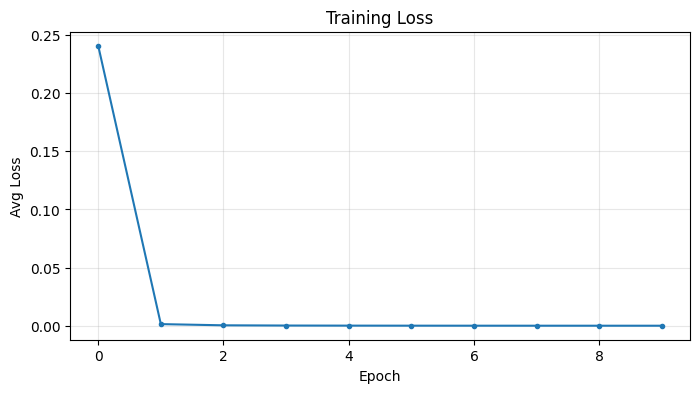

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Avg Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()


## 5. 评估

In [6]:
train_correct, train_total, train_acc = eval_samples(train_samples, encoder, decoder)
print(f"train accuracy: {train_correct}/{train_total} = {train_acc:.4f}")

train_char_acc = char_accuracy(train_samples, encoder, decoder)
print(f"train char_accuracy: {train_char_acc:.4f}")

test_correct, test_total, test_acc = eval_samples(test_samples, encoder, decoder)
print(f"test accuracy: {test_correct}/{test_total} = {test_acc:.4f}")

test_char_acc = char_accuracy(test_samples, encoder, decoder)
print(f"test char_accuracy: {test_char_acc:.4f}")


train accuracy: 1000/1000 = 1.0000
train char_accuracy: 1.0000
test accuracy: 100/100 = 1.0000
test char_accuracy: 1.0000


## 6. Attention 权重可视化

手动逐步运行 decoder，收集每一步的 attention 权重，绘制热力图。

- **横轴**：encoder 输入字符（`YYYY-MM-DD`）
- **纵轴**：decoder 输出字符（`DD/MM/YYYY`）
- **颜色**：attention 权重（越亮表示该输出字符越关注该输入字符）

如果模型学到了正确的对齐，热力图应该呈现明显的对角线模式——输出 `DD` 时关注输入的 `DD` 位置，输出 `MM` 时关注 `MM` 位置，输出 `YYYY` 时关注 `YYYY` 位置。

In [7]:
def collect_attention(input_str, encoder, decoder, max_len=20):
    """逐步运行 decoder，收集每步的 attention 权重。"""
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        input_tensor = tensor_from_string(input_str)
        encoder_output, _ = encoder(input_tensor)

        batch_size = encoder_output.shape[0]
        hidden = encoder_output[:, -1:].permute(1, 0, 2)
        input_token = torch.full((batch_size, 1), SOS_token, dtype=torch.long)

        attention_weights_all = []
        pred_tokens = []

        for i in range(max_len):
            # 手动执行 forward_step 以获取 attention 权重
            query = hidden[-1].unsqueeze(1)
            embedded = decoder.embedding(input_token)
            context = decoder.attention(query, encoder_output, encoder_output)
            # decoder.attention.attention_weights shape: (batch, input_len, 1)
            attention_weights_all.append(
                decoder.attention.attention_weights.squeeze(-1).squeeze(0)
            )

            context = context.unsqueeze(1)
            rnn_input = torch.cat([embedded, context], dim=-1)
            output, hidden = decoder.rnn(rnn_input, hidden)
            logits = decoder.out(hidden[-1])
            pred_token = logits.argmax(dim=-1, keepdim=True)

            pred_tokens.append(pred_token.item())
            if pred_token.item() == EOS_token:
                break
            input_token = pred_token

    attention_matrix = torch.stack(attention_weights_all)  # (output_len, input_len)
    return attention_matrix, pred_tokens


/var/folders/82/11bp845d2nx_vpqvdlywnj4r0000gn/T/ipykernel_27265/128510126.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


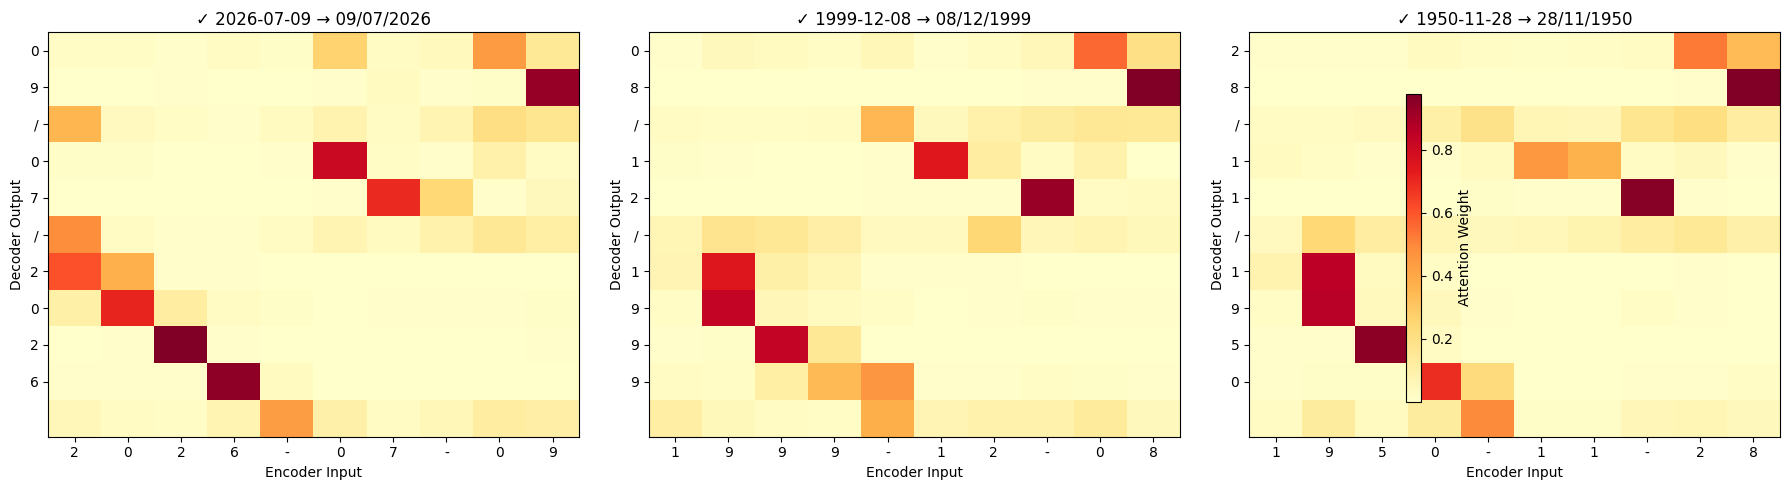

In [8]:
# 选取几个样本可视化 attention
viz_samples = [
    "2026-07-09",
    "1999-12-08",
    "1950-11-28",
]

fig, axes = plt.subplots(1, len(viz_samples), figsize=(6 * len(viz_samples), 5))
if len(viz_samples) == 1:
    axes = [axes]

for ax, input_str in zip(axes, viz_samples):
    attn_matrix, pred_tokens = collect_attention(input_str, encoder, decoder)

    # 构建输出字符串（排除 EOS）
    output_chars = [itos[t] for t in pred_tokens if t != EOS_token]
    output_str = "".join(output_chars)

    im = ax.imshow(attn_matrix.numpy(), cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(input_str)))
    ax.set_xticklabels(list(input_str))
    ax.set_yticks(range(len(output_chars)))
    ax.set_yticklabels(output_chars)
    ax.set_xlabel('Encoder Input')
    ax.set_ylabel('Decoder Output')
    correct = output_str == input_str[8:10] + "/" + input_str[5:7] + "/" + input_str[0:4]
    status = "✓" if correct else "✗"
    ax.set_title(f'{status} {input_str} → {output_str}')

fig.colorbar(im, ax=axes, label='Attention Weight', shrink=0.8)
plt.tight_layout()
plt.show()


EPOCH 5/10, avg_loss: 0.0001
input:   2002-01-23
pred:    23/01/2002
target:  23/01/2002
correct: True
---
input:   1999-12-08
pred:    08/12/1999
target:  08/12/1999
correct: True
---
input:   2020-03-07
pred:    07/03/2020
target:  07/03/2020
correct: True
---
input:   1950-11-28
pred:    28/11/1950
target:  28/11/1950
correct: True
---
input:   2048-06-15
pred:    15/06/2048
target:  15/06/2048
correct: True
...
pred:    15/06/2048
target:  15/06/2048
correct: True
---
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

train accuracy: 1000/1000 = 1.0000
train char_accuracy: 1.0000
test accuracy: 100/100 = 1.0000
test char_accuracy: 1.0000